<a href="https://colab.research.google.com/github/tacyataide/Revisao/blob/tacyataide-patch-1/Detec%C3%A7%C3%A3o_de_Blobs_usando_OpenCV_(Python%2C_C%2B%2B).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Detecção de Blobs com SimpleBlobDetector

Um **blob** é uma região formada por pixels conectados que possuem características semelhantes, como intensidade ou cor.

O `SimpleBlobDetector` do OpenCV permite detectar essas regiões e também filtrá-las de acordo com algumas características:

- **Área:** permite selecionar blobs de acordo com seu tamanho.
- **Circularidade:** mede o quanto o blob se aproxima do formato de um círculo.
- **Convexidade:** compara a área do blob com a área do seu casco convexo.
- **Inércia:** indica o quanto a forma é alongada.

O algoritmo realiza várias limiarizações da imagem, identifica regiões conectadas e combina regiões próximas para determinar os blobs finais.

No exemplo abaixo, carregamos uma imagem, configuramos os parâmetros do detector e desenhamos círculos sobre os blobs encontrados.

Saving BlobTest.jpg to BlobTest (1).jpg
Imagem original:


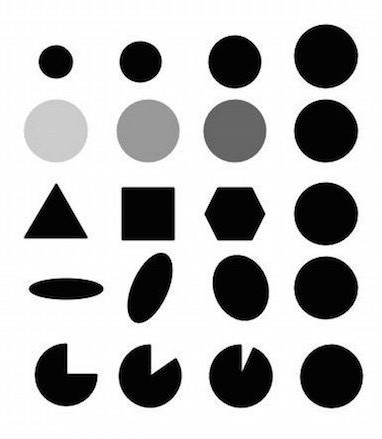

Resultado:


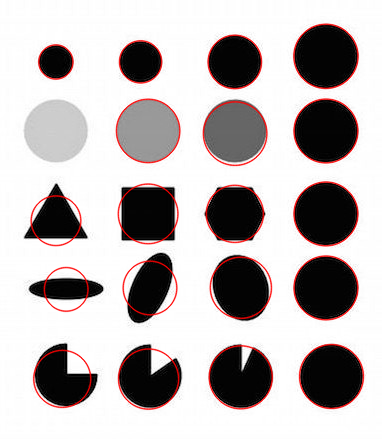

Blobs encontrados: 19


In [12]:
# Importar bibliotecas
import cv2
import numpy as np
from google.colab import files
from google.colab.patches import cv2_imshow

# Upload
uploaded = files.upload()
nome_imagem = next(iter(uploaded))

# Ler em escala de cinza
img = cv2.imread(nome_imagem, cv2.IMREAD_GRAYSCALE)

# Criar parâmetros
params = cv2.SimpleBlobDetector_Params()

# Limiares
params.minThreshold = 10
params.maxThreshold = 200

# Filtrar por área
params.filterByArea = True
params.minArea = 100

# Desativar outros filtros
params.filterByCircularity = False
params.filterByConvexity = False
params.filterByInertia = False

# Detectar blobs escuros
params.filterByColor = True
params.blobColor = 0

# Criar detector
detector = cv2.SimpleBlobDetector_create(params)

# Detectar
keypoints = detector.detect(img)

# Desenhar
resultado = cv2.drawKeypoints(
    img,
    keypoints,
    np.array([]),
    (0, 0, 255),
    cv2.DRAW_MATCHES_FLAGS_DRAW_RICH_KEYPOINTS
)

# Mostrar
print("Imagem original:")
cv2_imshow(img)

print("Resultado:")
cv2_imshow(resultado)

print("Blobs encontrados:", len(keypoints))

## Filtragem de Blobs por Características

O `SimpleBlobDetector` permite selecionar quais regiões da imagem serão consideradas blobs por meio da configuração de diferentes filtros.

Neste exemplo, são utilizados filtros de **cor, área, circularidade, convexidade e inércia**. Cada objeto precisa atender aos critérios dos filtros habilitados para ser considerado um blob válido.

- **Cor:** seleciona blobs escuros (`blobColor = 0`).
- **Área:** elimina objetos muito pequenos ou muito grandes.
- **Circularidade:** verifica o quanto a forma do objeto se aproxima de um círculo.
- **Convexidade:** verifica se o objeto possui poucas irregularidades ou concavidades.
- **Inércia:** permite diferenciar objetos mais circulares de objetos muito alongados.

Ao combinar esses filtros, algumas formas presentes na imagem podem não ser detectadas. Isso ocorre porque elas não atendem a pelo menos um dos critérios configurados.

Os círculos vermelhos indicam os blobs que passaram pelos filtros e foram detectados pelo algoritmo.

Dessa forma, a quantidade de blobs encontrados depende diretamente dos parâmetros utilizados no `SimpleBlobDetector`.

Saving BlobTest.jpg to BlobTest (5).jpg
Imagem original:


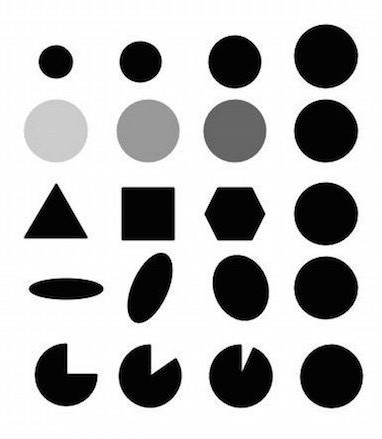

Blobs detectados:


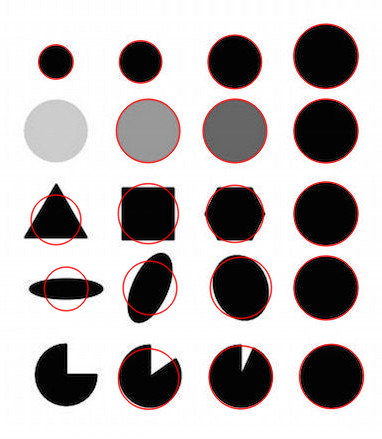

Quantidade de blobs encontrados: 18


In [16]:
import cv2
import numpy as np
from google.colab import files
from google.colab.patches import cv2_imshow

def criar_detector():
    params = cv2.SimpleBlobDetector_Params()

    params.minThreshold = 10
    params.maxThreshold = 200
    params.thresholdStep = 10

    params.minRepeatability = 2
    params.minDistBetweenBlobs = 10

    params.filterByColor = True
    params.blobColor = 0

    params.filterByArea = True
    params.minArea = 300
    params.maxArea = 5000

    params.filterByCircularity = True
    params.minCircularity = 0.1
    params.maxCircularity = 1.0

    params.filterByConvexity = True
    params.minConvexity = 0.87
    params.maxConvexity = 1.0

    params.filterByInertia = True
    params.minInertiaRatio = 0.01
    params.maxInertiaRatio = 1.0

    return cv2.SimpleBlobDetector_create(params)

uploaded = files.upload()
nome_imagem = next(iter(uploaded))

imagem = cv2.imread(nome_imagem, cv2.IMREAD_GRAYSCALE)

if imagem is None:
    raise FileNotFoundError(
        f"Não foi possível carregar a imagem: {nome_imagem}"
    )

detector = criar_detector()
keypoints = detector.detect(imagem)

resultado = cv2.drawKeypoints(
    imagem,
    keypoints,
    None,
    (0, 0, 255),
    cv2.DRAW_MATCHES_FLAGS_DRAW_RICH_KEYPOINTS
)

print("Imagem original:")
cv2_imshow(imagem)

print("Blobs detectados:")
cv2_imshow(resultado)

print("Quantidade de blobs encontrados:", len(keypoints))